In [20]:
from google.colab import userdata
api_key = userdata.get('test101')

In [21]:
pip install groq pandas openpyxl matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 3.7 MB/s eta 0:00:00


In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
FILE_PATH = '/content/drive/MyDrive/Bot/sample_sales_data.csv'

DATE_COL    = 'Date'
REVENUE_COL = 'Revenue'
UNITS_COL   = 'Units Sold'
REGION_COL  = 'Region'
PRODUCT_COL = 'Product'


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from datetime import date
import os

if FILE_PATH.endswith('.csv'):
    df = pd.read_csv(FILE_PATH, parse_dates=[DATE_COL])
else:
    df = pd.read_excel(FILE_PATH, parse_dates=[DATE_COL])

df = df.dropna(subset=[DATE_COL, REVENUE_COL])
df[REVENUE_COL] = pd.to_numeric(df[REVENUE_COL], errors='coerce').fillna(0)
if UNITS_COL in df.columns:
    df[UNITS_COL] = pd.to_numeric(df[UNITS_COL], errors='coerce').fillna(0)

print(f"Loaded {len(df)} rows from: {FILE_PATH}")
print(f"Date range: {df[DATE_COL].min().date()} → {df[DATE_COL].max().date()}")
df.head()

Loaded 28 rows from: /content/drive/MyDrive/Bot/sample_sales_data.csv
Date range: 2024-06-10 → 2024-06-16


,Date,Revenue,Units Sold,Region,Product
0,2024-06-10,85000,320,South,Product A
1,2024-06-10,62000,210,North,Product B
2,2024-06-10,41000,180,East,Product A
3,2024-06-10,33000,140,West,Product C
4,2024-06-11,91000,340,South,Product B


In [25]:
today     = df[DATE_COL].max()
yesterday = df[df[DATE_COL] == today]
prior     = df[df[DATE_COL] == today - pd.Timedelta(days=1)]
weekly    = df[df[DATE_COL] >= today - pd.Timedelta(days=6)]

total_rev  = yesterday[REVENUE_COL].sum()
prior_rev  = prior[REVENUE_COL].sum()
pct_change = round((total_rev - prior_rev) / prior_rev * 100, 1) if prior_rev else 0
units_sold = int(yesterday[UNITS_COL].sum()) if UNITS_COL in df.columns else 'N/A'
weekly_rev = weekly[REVENUE_COL].sum()

top_region  = (yesterday.groupby(REGION_COL)[REVENUE_COL].sum().idxmax()
               if REGION_COL in df.columns else 'N/A')
top_product = (yesterday.groupby(PRODUCT_COL)[REVENUE_COL].sum().idxmax()
               if PRODUCT_COL in df.columns else 'N/A')

print(f"Date        : {today.date()}")
print(f"Revenue     : ₹{total_rev:,.0f}  ({pct_change:+}% vs yesterday)")
print(f"Units sold  : {units_sold}")
print(f"Top region  : {top_region}")
print(f"Top product : {top_product}")
print(f"7-day total : ₹{weekly_rev:,.0f}")

Date        : 2024-06-16
Revenue     : ₹208,000  (-2.8% vs yesterday)
Units sold  : 750
Top region  : South
Top product : Product C
7-day total : ₹1,590,000


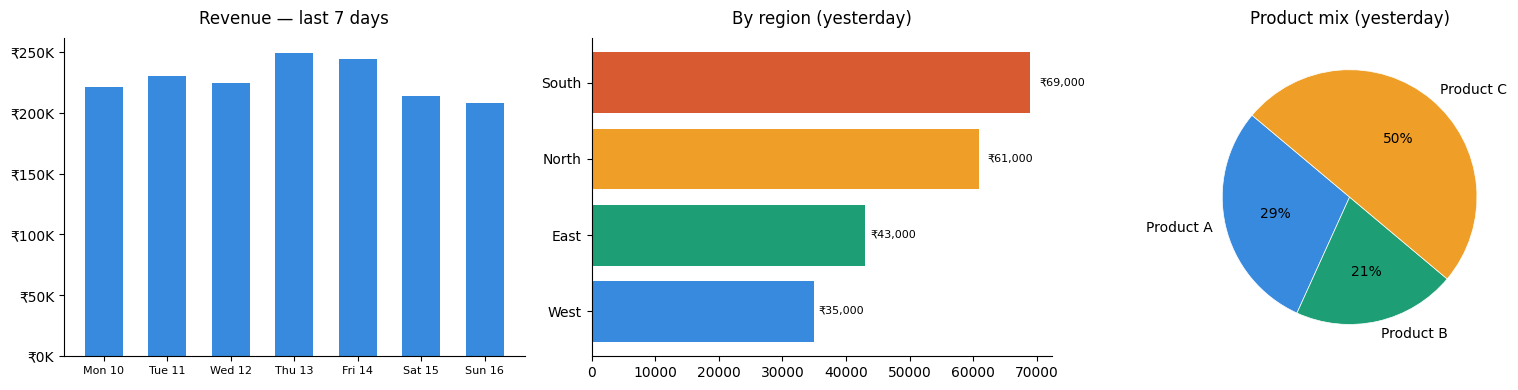

Charts saved.


In [26]:
COLORS = ['#378ADD', '#1D9E75', '#EF9F27', '#D85A30', '#7F77DD']
os.makedirs('charts', exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.patch.set_facecolor('white')

daily = weekly.groupby(DATE_COL)[REVENUE_COL].sum()
axes[0].bar(daily.index.strftime('%a %d'), daily.values, color=COLORS[0], width=0.6)
axes[0].set_title('Revenue — last 7 days', fontsize=12, fontweight='500', pad=10)
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].tick_params(axis='x', labelsize=8)

if REGION_COL in df.columns:
    by_region = yesterday.groupby(REGION_COL)[REVENUE_COL].sum().sort_values()
    bars = axes[1].barh(by_region.index, by_region.values,
                        color=COLORS[:len(by_region)])
    axes[1].set_title('By region (yesterday)', fontsize=12, fontweight='500', pad=10)
    axes[1].spines[['top', 'right']].set_visible(False)
    for bar in bars:
        axes[1].text(bar.get_width() * 1.02, bar.get_y() + bar.get_height() / 2,
                     f'₹{bar.get_width():,.0f}', va='center', fontsize=8)
else:
    axes[1].set_visible(False)

if PRODUCT_COL in df.columns:
    by_product = yesterday.groupby(PRODUCT_COL)[REVENUE_COL].sum()
    axes[2].pie(by_product, labels=by_product.index, autopct='%1.0f%%',
                colors=COLORS, startangle=140,
                wedgeprops={'linewidth': 0.5, 'edgecolor': 'white'})
    axes[2].set_title('Product mix (yesterday)', fontsize=12, fontweight='500', pad=10)
else:
    axes[2].set_visible(False)

plt.tight_layout()
plt.savefig('charts/report_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved.")

In [28]:
from google.colab import userdata
from groq import Groq

client = Groq(api_key=userdata.get('test101'))


prompt = f"""You are a data analyst writing a short daily business report.
Given the following stats for {today.date()}, write a 3-paragraph executive summary.

Stats:
- Total revenue: ₹{total_rev:,.0f} ({pct_change:+.1f}% vs yesterday)
- Units sold: {units_sold}
- Top region: {top_region}
- Top product: {top_product}
- 7-day cumulative revenue: ₹{weekly_rev:,.0f}

Rules:
1. Paragraph 1: What happened (headline number + trend).
2. Paragraph 2: What's driving it (top region/product, notable pattern).
3. Paragraph 3: One clear recommendation or watch-out for the team.
Keep it under 150 words. Be direct. No filler phrases."""

response = client.chat.completions.create(
    model='llama-3.3-70b-versatile',   # free, very capable
    messages=[{'role': 'user', 'content': prompt}],
    max_tokens=400
)
summary = response.choices[0].message.content
print(summary)

Revenue was ₹208,000, down 2.8% from yesterday.

The South region and Product C drove sales. Units sold were 750.

Monitor the South region's sales, as it may impact July revenue.


In [29]:
import base64

with open('charts/report_charts.png', 'rb') as f:
    chart_b64 = base64.b64encode(f.read()).decode()

arrow = '▲' if pct_change >= 0 else '▼'
trend_color = '#1D9E75' if pct_change >= 0 else '#D85A30'

html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8">
<title>Daily Report — {today.date()}</title>
<style>
  body {{
    font-family: -apple-system, Arial, sans-serif;
    max-width: 740px; margin: 40px auto;
    padding: 0 20px; background: #f7f7f5; color: #1a1a1a;
  }}
  .card {{
    background: #fff; border: 0.5px solid #e0dfd8;
    border-radius: 12px; padding: 20px 24px; margin-bottom: 20px;
  }}
  .label {{
    font-size: 11px; text-transform: uppercase;
    letter-spacing: .06em; color: #888; margin-bottom: 4px;
  }}
  .grid {{ display: grid; grid-template-columns: repeat(3,1fr); gap: 12px; margin-bottom: 20px; }}
  .metric {{
    background: #f7f7f5; border-radius: 8px; padding: 14px 16px;
  }}
  .metric .val {{ font-size: 20px; font-weight: 500; }}
  .metric .sub {{ font-size: 12px; color: #888; margin-top: 2px; }}
  p {{ line-height: 1.7; font-size: 15px; color: #333; }}
  h2 {{ font-size: 14px; font-weight: 500; color: #555; margin: 0 0 12px; }}
  img {{ width: 100%; border-radius: 8px; margin-top: 8px; }}
  .footer {{ font-size: 12px; color: #aaa; text-align: center; margin-top: 32px; }}
</style>
</head>
<body>

<div style="margin-bottom:24px;">
  <div style="font-size:12px;color:#888;">Daily sales report</div>
  <div style="font-size:22px;font-weight:500;">{today.date()}</div>
</div>

<div class="card">
  <div class="label">Total revenue</div>
  <div style="font-size:28px;font-weight:500;">
    ₹{total_rev:,.0f}
    <span style="font-size:16px;color:{trend_color};">
      {arrow} {abs(pct_change)}% vs yesterday
    </span>
  </div>
</div>

<div class="grid">
  <div class="metric">
    <div class="label">Units sold</div>
    <div class="val">{units_sold:,}</div>
    <div class="sub">yesterday</div>
  </div>
  <div class="metric">
    <div class="label">Top region</div>
    <div class="val" style="font-size:16px;">{top_region}</div>
    <div class="sub">by revenue</div>
  </div>
  <div class="metric">
    <div class="label">7-day total</div>
    <div class="val" style="font-size:16px;">₹{weekly_rev:,.0f}</div>
    <div class="sub">rolling week</div>
  </div>
</div>

<div class="card">
  <h2>AI summary</h2>
  {''.join(f'<p>{p.strip()}</p>' for p in summary.strip().split(chr(10)) if p.strip())}
</div>

<div class="card">
  <h2>Charts</h2>
  <img src="data:image/png;base64,{chart_b64}" alt="Report charts">
</div>

<div class="footer">Auto-generated by Daily Report Bot · {today.date()}</div>

</body>
</html>"""

# Save to Drive so you keep a copy every day
report_filename = f'daily_report_{today.date()}.html'
drive_output    = f'/content/drive/MyDrive/{report_filename}'

with open(report_filename, 'w') as f:
    f.write(html)

# Also save a copy back to Google Drive
with open(drive_output, 'w') as f:
    f.write(html)

print(f"Report saved locally: {report_filename}")
print(f"Report saved to Drive: {drive_output}")

Report saved locally: daily_report_2024-06-16.html
Report saved to Drive: /content/drive/MyDrive/daily_report_2024-06-16.html


In [30]:
from google.colab import files
files.download(report_filename)
print("Done! Check your downloads folder.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done! Check your downloads folder.
